# Clustering Tuning Explorer

Esplorazione interattiva di sweep di tuning **già eseguite**.

## Helper

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Repo root isn't on sys.path when this notebook runs with cwd=notebooks/post-results_analysis/ -
# same fix as clustering_evaluation.ipynb / temp/*/run_prototype.py.
NOTEBOOK_REPO_ROOT = Path.cwd().resolve().parents[1]
if str(NOTEBOOK_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_REPO_ROOT))

pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)

In [2]:

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

from src.analysis.clustering import CLUSTERING_METHODS
from src.analysis.consensus_clustering import subsampling_stability_index
from src.utils.artifacts import load_matrix


def show_images(run_dir: Path, image_names: list[str]) -> None:
    """Displays one or more diagnostic images from the same run side by side (e.g. one
    dendrogram per linkage, or a single interclass_distance_matrix.png). Raises if any
    is missing rather than skipping it."""
    fig, axes = plt.subplots(1, len(image_names), figsize=(7 * len(image_names), 7))
    axes = [axes] if len(image_names) == 1 else axes
    for ax, image_name in zip(axes, image_names):
        image_path = run_dir / image_name
        if not image_path.is_file():
            raise FileNotFoundError(f"{image_name!r} not found in {run_dir}")
        ax.imshow(plt.imread(image_path))
        ax.set_title(image_name, fontsize=10)
        ax.axis("off")
    fig.tight_layout()
    plt.show()


def load_tuning_results(run_dirs: list[Path]) -> pd.DataFrame:
    """Reads tuning_results.csv from each run dir and concatenates them, tagged by a
    `run` column (the run dir's own name, e.g. "31-08_s1.1-vol_euclidean_n10")."""
    frames = []
    for run_dir in run_dirs:
        csv_path = run_dir / "tuning_results.csv"
        if not csv_path.is_file():
            raise FileNotFoundError(f"no tuning_results.csv in {run_dir}")
        df = pd.read_csv(csv_path)
        df.insert(0, "run", run_dir.name)
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


def list_combo_keys(run_dir: Path) -> list[str]:
    """Lists every combination key saved in a run's clusterings.npz (save_tuning_clusterings:
    true), e.g. "n_clusters=2,linkage=average,metric=cosine" - use to find the exact key for
    crosstab_run below."""
    npz_path = run_dir / "clusterings.npz"
    if not npz_path.is_file():
        raise FileNotFoundError(f"no clusterings.npz in {run_dir} - rerun tuning with save_tuning_clusterings=true")
    return sorted(np.load(npz_path).keys())


def crosstab_run(run_dir: Path, combo_key: str, metadata_column: str) -> pd.DataFrame:
    """Cross-tabulates one tuning combination's cluster labels against a metadata column,
    to check whether a candidate n_clusters is tracking a known confound (e.g. lesion_side)
    instead of genuine structure. `combo_key` must match a key in clusterings.npz exactly -
    see list_combo_keys(run_dir)."""
    npz_path = run_dir / "clusterings.npz"
    if not npz_path.is_file():
        raise FileNotFoundError(f"no clusterings.npz in {run_dir} - rerun tuning with save_tuning_clusterings=true")
    metadata_path = run_dir / "metadata.csv"
    if not metadata_path.is_file():
        raise FileNotFoundError(f"no metadata.csv in {run_dir}")

    z = np.load(npz_path)
    if combo_key not in z:
        raise KeyError(f"{combo_key!r} not in {npz_path} - available keys: {sorted(z.keys())}")
    labels = z[combo_key]

    metadata = pd.read_csv(metadata_path)
    if metadata_column not in metadata.columns:
        raise KeyError(f"{metadata_column!r} not a column in {metadata_path} - available: {list(metadata.columns)}")

    return pd.crosstab(labels, metadata[metadata_column])

def compare_combos(run_dir: Path, combo_key_a: str, combo_key_b: str) -> dict[str, float]:
    """ARI + NMI between two combinations' cluster labels from the same run's
    clusterings.npz - quantifies "how similar are these two candidates" instead of eyeballing
    two crosstabs side by side (e.g. does average/ward really converge on the same partition,
    or just look similar?). Raises if either key is missing."""
    npz_path = run_dir / "clusterings.npz"
    if not npz_path.is_file():
        raise FileNotFoundError(f"no clusterings.npz in {run_dir} - rerun tuning with save_tuning_clusterings=true")
    z = np.load(npz_path)
    for key in (combo_key_a, combo_key_b):
        if key not in z:
            raise KeyError(f"{key!r} not in {npz_path} - available keys: {sorted(z.keys())}")
    labels_a, labels_b = z[combo_key_a], z[combo_key_b]
    return {
        "ari": adjusted_rand_score(labels_a, labels_b),
        "nmi": normalized_mutual_info_score(labels_a, labels_b),
    }


def _read_tuning_config(run_dir: Path) -> dict:
    """Parses the JSON config block embedded in a tuning run's config.md (a fenced ```json
    block) - a different format from production's "Params used:" line
    (src.utils.artifacts.read_run_params), so not directly reusable here."""
    config_path = run_dir / "config.md"
    if not config_path.is_file():
        raise FileNotFoundError(f"no config.md in {run_dir}")
    text = config_path.read_text()
    if "```json" not in text:
        raise ValueError(f"{config_path} has no ```json config block")
    block = text.split("```json", 1)[1].split("```", 1)[0]
    return json.loads(block)


def _parse_combo_key(combo_key: str) -> dict:
    """Converts a clusterings.npz key like "n_clusters=5,linkage=average,metric=euclidean"
    into a params dict for CLUSTERING_METHODS, casting each value to int/float when possible,
    else leaving it as a string."""
    params = {}
    for part in combo_key.split(","):
        name, value = part.split("=")
        try:
            params[name] = int(value)
        except ValueError:
            try:
                params[name] = float(value)
            except ValueError:
                params[name] = value
    return params


def stability_check(run_dir: Path, combo_key: str, subsample_fraction: float = 0.8) -> float:
    """Subsampling Stability Index (see clustering_evaluation.ipynb §5) for one tuning
    combination - refits the same method/params on an 80% subsample of the same embedding
    this run swept over (its own config.md `input_path`, loaded via load_matrix - the same
    contract clustering.py/embedding_app.py use) and scores ARI against a full-sample fit.
    Doesn't require a production run to exist first - works directly on a tuning combo.
    A value near 1 means the clustering doesn't depend on which subjects happened to be
    sampled; a low value is a reason to look closer, not to discard the candidate outright."""
    config = _read_tuning_config(run_dir)
    input_path = NOTEBOOK_REPO_ROOT / config["input_path"]

    X, embedding_metadata, _extra_arrays = load_matrix(input_path)
    tuning_metadata = pd.read_csv(run_dir / "metadata.csv")
    if not embedding_metadata["subject_id"].equals(tuning_metadata["subject_id"]):
        raise ValueError(
            f"{input_path}'s subject_id order doesn't match {run_dir}/metadata.csv - "
            "can't reuse X positionally for this run"
        )

    return subsampling_stability_index(config["clustering_method"], X, _parse_combo_key(combo_key), subsample_fraction)


def crosstab_refit(run_dir: Path, params: dict, metadata_column: str) -> pd.DataFrame:
    """Same purpose as crosstab_run, for a run with no saved clusterings.npz (spectral with
    `affinity` swept has save_tuning_clusterings disabled by design, docs/dev/models.md) -
    refits the given combination directly via CLUSTERING_METHODS instead of reading saved
    labels. `params` is a plain dict (e.g. {"n_clusters": 6, "affinity": "rbf", "gamma": 1.0}),
    not a clusterings.npz key string - there is no saved key to copy from here."""
    config = _read_tuning_config(run_dir)
    X, metadata, _extra_arrays = load_matrix(NOTEBOOK_REPO_ROOT / config["input_path"])
    if metadata_column not in metadata.columns:
        raise KeyError(f"{metadata_column!r} not a column in metadata - available: {list(metadata.columns)}")
    labels = CLUSTERING_METHODS[config["clustering_method"]](X, params)
    return pd.crosstab(labels, metadata[metadata_column])

## Agglomerative

### 0. Scegli l'embedding da analizzare

Un solo `RUN_DIR` alla volta per le sezioni 1-6 (metric → linkage → n_clusters → artefatto →
confronto tra combinazioni → stabilità) - il confronto tra più embedding è in fondo, sezione 7.

Esempio: `31-08_s1.1-vol_euclidean_n3` - non ancora controllata nelle sessioni precedenti
(`n2`/`n10` euclidean e tutti e 3 i `dice` erano già stati fatti).

In [3]:
RUN_DIR = NOTEBOOK_REPO_ROOT / "results/sdc/clustering/tuning/agglomerative/umap/01-09_s2.1-schaefer-200-tian-s2_m_euclidean_nc2"

if not RUN_DIR.is_dir():
    raise FileNotFoundError(f"run directory not found: {RUN_DIR}")

results = pd.read_csv(RUN_DIR / "tuning_results.csv")
print(f"{len(results)} righe, metric sweepate: {sorted(results['metric'].unique())}, linkage sweepate: {sorted(results['linkage'].unique())}")

70 righe, metric sweepate: ['cosine', 'euclidean', 'manhattan'], linkage sweepate: ['average', 'complete', 'single', 'ward']


### 1. Quale `metric` guardare per prima? (interclass distance matrix)

**Cosa mostra:** un heatmap per ogni `metric` sweepata (euclidean/cosine/manhattan) — righe/colonne = valori di `dataset`, cella = distanza media tra i soggetti dei due gruppi (diagonale = dentro lo stesso `dataset`). Pre-check indipendente dal fit, non dice nulla su `n_clusters`.
**Come leggerlo:** la `metric` migliore tiene la diagonale bassa e le celle fuori diagonale alte.

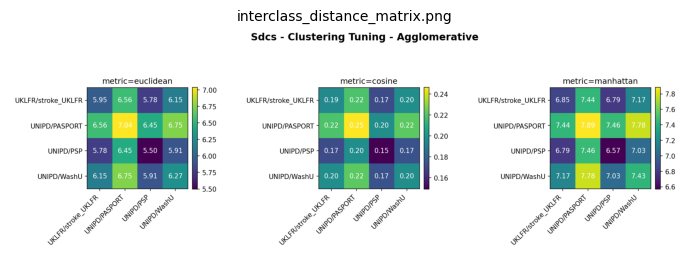

In [4]:
show_images(RUN_DIR, ["interclass_distance_matrix.png"])

### 2. `linkage`, dato un `metric` (dendrogrammi)

**Cosa mostra:** un file per `metric` sweepata, un subplot per `linkage` valido — dendrogramma troncato alle ultime 30 fusioni (non l'albero completo), asse y = distanza di fusione.
**Come leggerlo:** il salto verticale più grande tra due fusioni indica il taglio più naturale (vicino alla cima → 2 cluster). `single` va quasi sempre scartato (chaining) — guardalo comunque, non darlo per scontato.

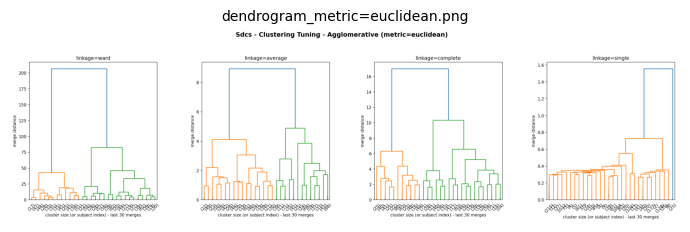

In [5]:
METRIC = "euclidean"
show_images(RUN_DIR, [f"dendrogram_metric={METRIC}.png"])

### 3. `n_clusters`, dentro il `metric` scelto

**Cosa mostra:** tabella `results` filtrata sulla `metric` scelta in sezione 1 (`single` escluso) — Silhouette/Calinski-Harabasz/Davies-Bouldin per ogni `n_clusters`/`linkage`. Nessun plot qui: 3 parametri sweepati insieme (`n_clusters`×`linkage`×`metric`) sono troppi per un grafico aggregato (CH/DB sono `NaN` se `metric != "euclidean"` — non è un bug).
**Come leggerlo:** Silhouette vicino a 1 = cluster compatti/separati (unico dei tre interpretabile da solo); CH cresce quasi sempre con k (solo conferma); DB più basso = meglio.

In [6]:
METRIC = "euclidean"

(
    results[(results["metric"] == METRIC) & (results["linkage"] != "single")]
    .sort_values(["linkage", "n_clusters"])
)

,n_clusters,linkage,metric,silhouette,noise_fraction,calinski_harabasz,davies_bouldin
1,2,average,euclidean,0.608349,0.0,3150.366556,0.542535
11,3,average,euclidean,0.496604,0.0,2804.429183,0.621912
21,4,average,euclidean,0.496324,0.0,3396.916324,0.695773
31,5,average,euclidean,0.478493,0.0,2899.518075,0.630061
41,6,average,euclidean,0.473851,0.0,2961.777575,0.594977
51,8,average,euclidean,0.450538,0.0,3250.757845,0.640266
61,10,average,euclidean,0.446151,0.0,3706.794698,0.700107
4,2,complete,euclidean,0.621457,0.0,3149.005266,0.493919
14,3,complete,euclidean,0.536141,0.0,3291.122466,0.616614
24,4,complete,euclidean,0.487369,0.0,3121.604664,0.636983


### 4. Check artefatto: crosstab del `k` candidato contro i metadati

**Cosa mostra:** quanti soggetti di ogni cluster cadono in ciascuna categoria di una colonna di metadati (es. `lesion_side`).
**Come leggerlo:** se un cluster è quasi tutto in una sola categoria, quel `k` sta solo ritrovando un'informazione già nei metadati, non struttura nuova.

In [7]:
list_combo_keys(RUN_DIR)[:10]  # per trovare il COMBO_KEY esatto sotto

['n_clusters=10,linkage=average,metric=cosine',
 'n_clusters=10,linkage=average,metric=euclidean',
 'n_clusters=10,linkage=average,metric=manhattan',
 'n_clusters=10,linkage=complete,metric=cosine',
 'n_clusters=10,linkage=complete,metric=euclidean',
 'n_clusters=10,linkage=complete,metric=manhattan',
 'n_clusters=10,linkage=single,metric=cosine',
 'n_clusters=10,linkage=single,metric=euclidean',
 'n_clusters=10,linkage=single,metric=manhattan',
 'n_clusters=10,linkage=ward,metric=euclidean']

In [8]:
COMBO_KEY = "n_clusters=2,linkage=complete,metric=cosine"
METADATA_COLUMN = "lesion_side"

crosstab_run(RUN_DIR, COMBO_KEY, METADATA_COLUMN)

lesion_side,left,right,unknown
row_0,,,
0,5,348,66
1,525,48,127


### 5. Confronto quantitativo tra combinazioni (ARI/NMI)

**Cosa mostra:** accordo tra due partizioni della stessa sweep (es. due `linkage` allo stesso `k`, o due `k` vicini) — sostituisce il confronto a occhio tra due crosstab.

**Come leggerlo:** 0 = nessun accordo oltre il caso, 1 = partizioni identiche.

In [9]:
COMBO_KEY_A = "n_clusters=5,linkage=average,metric=euclidean"
COMBO_KEY_B = "n_clusters=5,linkage=ward,metric=euclidean"

compare_combos(RUN_DIR, COMBO_KEY_A, COMBO_KEY_B)

{'ari': 0.7707952089751404, 'nmi': 0.822231193483902}

### 6. Subsampling Stability Index

**Cosa mostra:** ARI tra il fit sul 100% dei soggetti e un rifit sull'80% (subsample casuale, senza reinserimento).

**Come leggerlo:** vicino a 1 = il clustering non dipende da chi capita nel campione (es. outlier); basso = segnale da approfondire, non un motivo per scartare subito il candidato.

In [10]:
COMBO_KEY = "n_clusters=5,linkage=ward,metric=euclidean"

stability_check(RUN_DIR, COMBO_KEY, subsample_fraction=0.8)

0.994166345634157

### 7. Vista globale multi-embedding

**Cosa mostra:** lo stesso check (tabella o immagine) fianco a fianco su più `RUN_DIRS` (`n_components`/`metric` diversi) — solo dopo aver fatto 1-4 su ciascun embedding separatamente.

**Come leggerlo:** solo qualitativo, spazi diversi non sono numericamente confrontabili — serve a vedere se un `k` sopravvissuto al check si ripete su più embedding.

In [11]:
RUN_DIRS = [
    NOTEBOOK_REPO_ROOT / "results/sdc/clustering/tuning/agglomerative/umap/01-09_s2.1-schaefer-200-tian-s2_m_euclidean_nc2",
    NOTEBOOK_REPO_ROOT / "results/sdc/clustering/tuning/agglomerative/umap/01-09_s2.1-schaefer-200-tian-s2_m_euclidean_nc2",
    NOTEBOOK_REPO_ROOT / "results/sdc/clustering/tuning/agglomerative/umap/01-09_s2.1-schaefer-200-tian-s2_m_euclidean_nc2",
]
for run_dir in RUN_DIRS:
    if not run_dir.is_dir():
        raise FileNotFoundError(f"run directory not found: {run_dir}")

all_results = load_tuning_results(RUN_DIRS)
print(f"{len(all_results)} righe, run: {sorted(all_results['run'].unique())}")
all_results[all_results["linkage"] != "single"].sort_values("silhouette", ascending=False).groupby(["run", "metric"]).head(1)

210 righe, run: ['01-09_s2.1_m_euclidean_nc2']


,run,n_clusters,linkage,metric,silhouette,noise_fraction,calinski_harabasz,davies_bouldin
145,01-09_s2.1_m_euclidean_nc2,2,complete,cosine,0.826689,0.0,NaN,NaN
74,01-09_s2.1_m_euclidean_nc2,2,complete,euclidean,0.621457,0.0,3149.005266,0.493919
146,01-09_s2.1_m_euclidean_nc2,2,complete,manhattan,0.597597,0.0,NaN,NaN


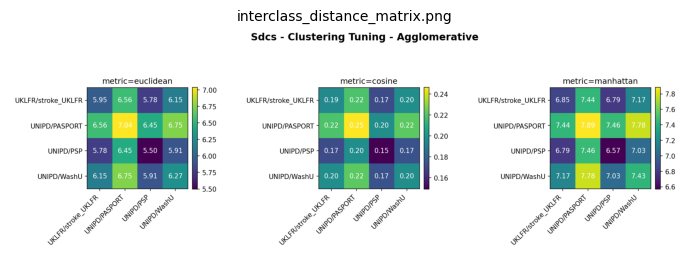

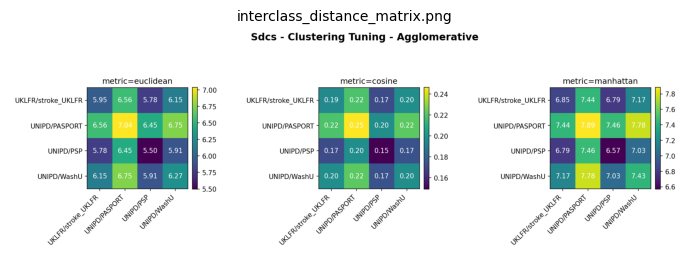

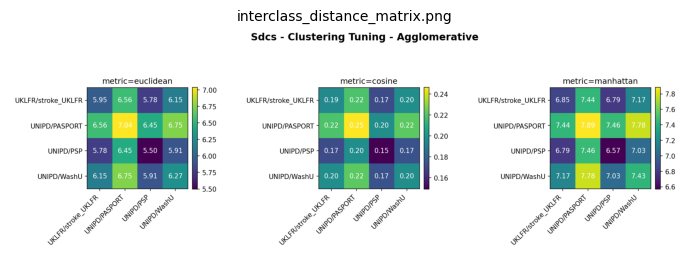

In [12]:
IMAGE_NAME = "interclass_distance_matrix.png"
for run_dir in RUN_DIRS:
    show_images(run_dir, [IMAGE_NAME])

## GMM

Ordine diverso da agglomerative: **stabilità prima di tutto** (GMM converge a un ottimo *locale*
via EM, dipende dal seed più di quanto n_clusters da solo suggerisca), poi `covariance_type`
(comparabile direttamente via BIC/AIC, niente pre-check dedicato tipo interclass-matrix), poi
`n_components`, poi il solito check artefatto.

### 0. Scegli l'embedding

Stesso discorso di agglomerative: `dice`/`euclidean` × `n_components` (UMAP) non sono
comparabili numericamente tra loro, solo qualitativamente.

In [13]:
RUN_DIR = NOTEBOOK_REPO_ROOT / "results/sdc/clustering/tuning/gmm/umap/01-09_s2.1-schaefer-200-tian-s2_m_euclidean_nc2"

if not RUN_DIR.is_dir():
    raise FileNotFoundError(f"run directory not found: {RUN_DIR}")

results = pd.read_csv(RUN_DIR / "tuning_results.csv")
print(
    f"{len(results)} righe, covariance_type sweepate: {sorted(results['covariance_type'].unique())}, "
    f"n_components sweepate: {sorted(results['n_components'].unique())}"
)

28 righe, covariance_type sweepate: ['diag', 'full', 'spherical', 'tied'], n_components sweepate: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(10)]


### 1. Stabilità dell'inizializzazione (`init_params`/`n_init`)

**Cosa mostra:** `stability_plot.png` 
    — BIC per 3 `n_components` rappresentativi (min/mediana/max della griglia)
    una linea per `init_params` (`kmeans` vs `random`), errorbar su `n_init`.

**Come leggerlo:** una linea che si appiattisce presto e resta bassa = inizializzazione stabile; se resta alta, i punteggi della sweep principale per quel `n_components` dipendono più dal seed che dal vero numero di cluster.

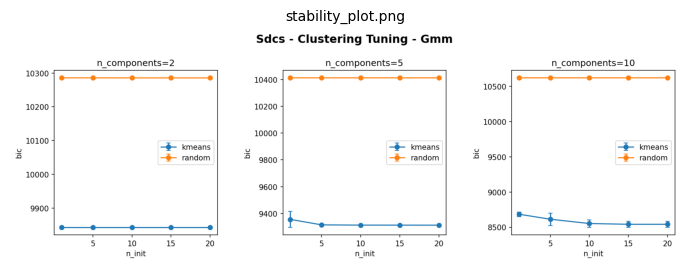

In [14]:
show_images(RUN_DIR, ["stability_plot.png"])

### 2. `covariance_type`

**Cosa mostra:** `tuning_plot.png` — heatmap, un subplot per Silhouette/CH/DB/BIC/AIC, asse x = `n_components`, asse y = `covariance_type`, colore = valore della metrica.
**Come leggerlo:** per BIC/AIC più basso = meglio — a differenza di agglomerative, qui sono lo strumento statistico corretto per confrontare `covariance_type` (penalizzano la complessità del modello). Guarda quale riga (`covariance_type`) ha in media i colori migliori lungo `n_components`.

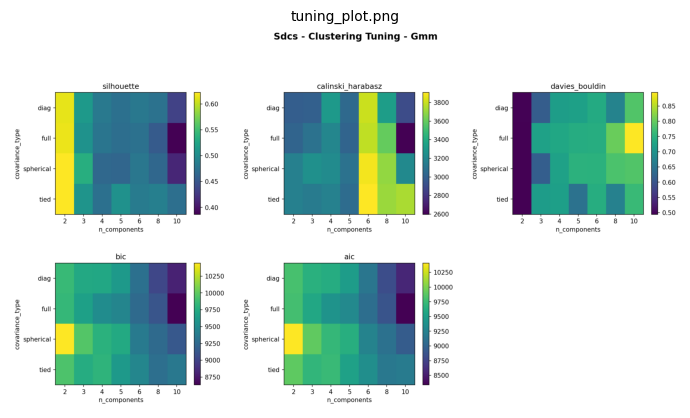

In [15]:
show_images(RUN_DIR, ["tuning_plot.png"])

In [16]:
results.sort_values(["covariance_type", "n_components"])

,n_components,covariance_type,silhouette,calinski_harabasz,davies_bouldin,noise_fraction,bic,aic
2,2,diag,0.613415,2990.842612,0.496404,0.0,9853.912009,9808.730292
6,3,diag,0.512956,2997.006516,0.612706,0.0,9724.360605,9654.077935
10,4,diag,0.482274,3299.024219,0.716917,0.0,9719.521970,9624.138347
14,5,diag,0.473141,3044.031204,0.722402,0.0,9606.842391,9486.357814
18,6,diag,0.480881,3800.170972,0.739141,0.0,9299.619259,9154.033729
22,8,diag,0.475198,3326.586454,0.673554,0.0,9022.873604,8827.086166
26,10,diag,0.432835,2901.154499,0.785994,0.0,8810.314514,8564.325170
0,2,full,0.614936,3019.811260,0.495905,0.0,9842.800459,9787.578362
4,3,full,0.506844,3093.096750,0.723794,0.0,9664.728823,9579.385581
8,4,full,0.478283,3201.084077,0.732011,0.0,9517.872730,9402.408343


### 3. `n_components`

**Cosa mostra:** dalla tabella `results`, il `n_components` a Silhouette più alta per ciascun `covariance_type` (non ricalcolato da BIC/AIC in questa cella).
**Come leggerlo:** confronta questo pick con la heatmap BIC/AIC della sezione 2 — se non coincidono (Silhouette alto ma BIC lontano dal minimo per quella riga), preferisci BIC/AIC come criterio primario, è quello statisticamente corretto per questo confronto.

In [17]:
results.sort_values("silhouette", ascending=False).groupby("covariance_type").head(1)

,n_components,covariance_type,silhouette,calinski_harabasz,davies_bouldin,noise_fraction,bic,aic
3,2,spherical,0.621965,3170.311241,0.494629,0.0,10444.131585,10408.990250
1,2,tied,0.621965,3170.311241,0.494629,0.0,9935.651914,9895.490388
0,2,full,0.614936,3019.811260,0.495905,0.0,9842.800459,9787.578362
2,2,diag,0.613415,2990.842612,0.496404,0.0,9853.912009,9808.730292


### 4. Check artefatto: crosstab del candidato contro i metadati

Stesso check della sezione 4 di agglomerative: un cluster quasi puro su una categoria di metadati = artefatto, non struttura nuova.

In [18]:
list_combo_keys(RUN_DIR)[:10]  # per trovare il COMBO_KEY esatto sotto

['n_components=10,covariance_type=diag',
 'n_components=10,covariance_type=full',
 'n_components=10,covariance_type=spherical',
 'n_components=10,covariance_type=tied',
 'n_components=2,covariance_type=diag',
 'n_components=2,covariance_type=full',
 'n_components=2,covariance_type=spherical',
 'n_components=2,covariance_type=tied',
 'n_components=3,covariance_type=diag',
 'n_components=3,covariance_type=full']

In [19]:
COMBO_KEY = "n_components=4,covariance_type=full"
METADATA_COLUMN = "lesion_side"

crosstab_run(RUN_DIR, COMBO_KEY, METADATA_COLUMN)

lesion_side,left,right,unknown
row_0,,,
0,62,123,51
1,188,0,46
2,279,6,48
3,1,267,48


### 5. Vista globale multi-embedding

**Cosa mostra:** lo stesso check (tabella e `stability_plot.png`) fianco a fianco su più `RUN_DIRS` (`n_components` diversi, `metric=euclidean`) — miglior `n_components` per Silhouette in ciascun `covariance_type`, per ciascun embedding.
**Come leggerlo:** solo qualitativo, spazi diversi non sono numericamente confrontabili — serve a vedere se un candidato (`n_components`, `covariance_type`) sopravvissuto al check si ripete su più embedding.

In [20]:
RUN_DIRS = [
    NOTEBOOK_REPO_ROOT / "results/sdc/clustering/tuning/gmm/umap/01-09_s2.1-schaefer-200-tian-s2_m_euclidean_nc2",
    NOTEBOOK_REPO_ROOT / "results/sdc/clustering/tuning/gmm/umap/01-09_s2.1-schaefer-200-tian-s2_m_euclidean_nc2",
    NOTEBOOK_REPO_ROOT / "results/sdc/clustering/tuning/gmm/umap/01-09_s2.1-schaefer-200-tian-s2_m_euclidean_nc2",
]
for run_dir in RUN_DIRS:
    if not run_dir.is_dir():
        raise FileNotFoundError(f"run directory not found: {run_dir}")

all_results = load_tuning_results(RUN_DIRS)
print(f"{len(all_results)} righe, run: {sorted(all_results['run'].unique())}")
all_results.sort_values("silhouette", ascending=False).groupby(["run", "covariance_type"]).head(1)

84 righe, run: ['01-09_s2.1_m_euclidean_nc2']


,run,n_components,covariance_type,silhouette,calinski_harabasz,davies_bouldin,noise_fraction,bic,aic
57,01-09_s2.1_m_euclidean_nc2,2,tied,0.621965,3170.311241,0.494629,0.0,9935.651914,9895.490388
59,01-09_s2.1_m_euclidean_nc2,2,spherical,0.621965,3170.311241,0.494629,0.0,10444.131585,10408.990250
56,01-09_s2.1_m_euclidean_nc2,2,full,0.614936,3019.811260,0.495905,0.0,9842.800459,9787.578362
30,01-09_s2.1_m_euclidean_nc2,2,diag,0.613415,2990.842612,0.496404,0.0,9853.912009,9808.730292


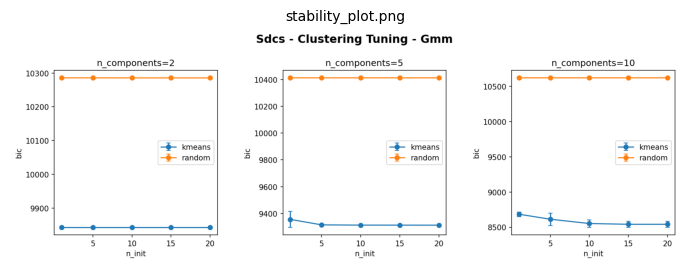

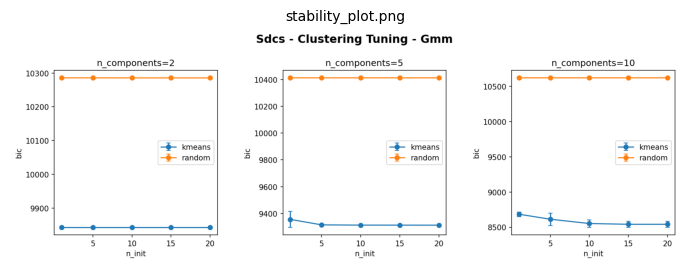

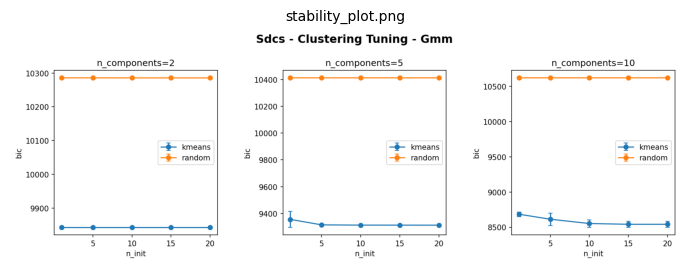

In [21]:
IMAGE_NAME = "stability_plot.png"
for run_dir in RUN_DIRS:
    show_images(run_dir, [IMAGE_NAME])

## KMeans

Il più semplice dei 5: un solo parametro sweepato (`n_clusters`), niente equivalente di
`metric`/`covariance_type` da gestire. Stessa ragione di GMM per la stabilità (EM/inizializzazione
casuale → minimo locale dell'inerzia), quindi stessa priorità: stabilità prima di tutto.

### 0. Scegli l'embedding

In [22]:
RUN_DIR = NOTEBOOK_REPO_ROOT / "results/sdc/clustering/tuning/kmeans/umap/01-09_s2.1-schaefer-200-tian-s2_m_euclidean_nc2"

if not RUN_DIR.is_dir():
    raise FileNotFoundError(f"run directory not found: {RUN_DIR}")

results = pd.read_csv(RUN_DIR / "tuning_results.csv")
print(f"{len(results)} righe, n_clusters sweepate: {sorted(results['n_clusters'].unique())}")

7 righe, n_clusters sweepate: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(10)]


### 1. Stabilità dell'inizializzazione (`init`/`n_init`)

**Cosa mostra:** `stability_plot.png` — 3 pannelli, uno per ogni `n_clusters` rappresentativo (min/mediana/max della griglia). In ogni pannello: asse x = `n_init`, asse y = inertia (media ± deviazione standard su più ripetizioni a seed diversi), una linea per `init` (`k-means++` vs `random`).
**Come leggerlo:** una linea che si appiattisce presto e resta bassa = l'inerzia non dipende più dal seed, inizializzazione stabile.

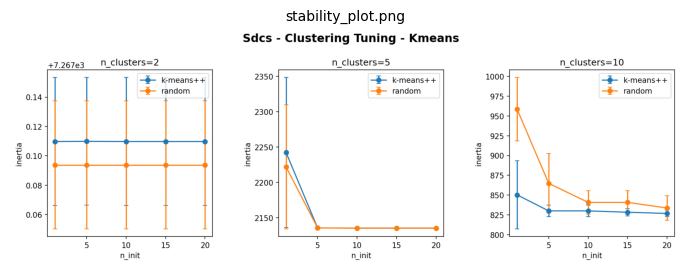

In [23]:
show_images(RUN_DIR, ["stability_plot.png"])

### 2. `n_clusters`

**Cosa mostra:** `tuning_plot.png` — un subplot per Silhouette/CH/DB/`inertia`, tutti con asse x = `n_clusters` (`inertia` è l'elbow plot: stessa colonna già in tabella, nessun file a parte).
**Come leggerlo:** `inertia` scende sempre con k — cerca il gomito (dove smette di scendere ripidamente), non il minimo, e incrocialo con Silhouette.

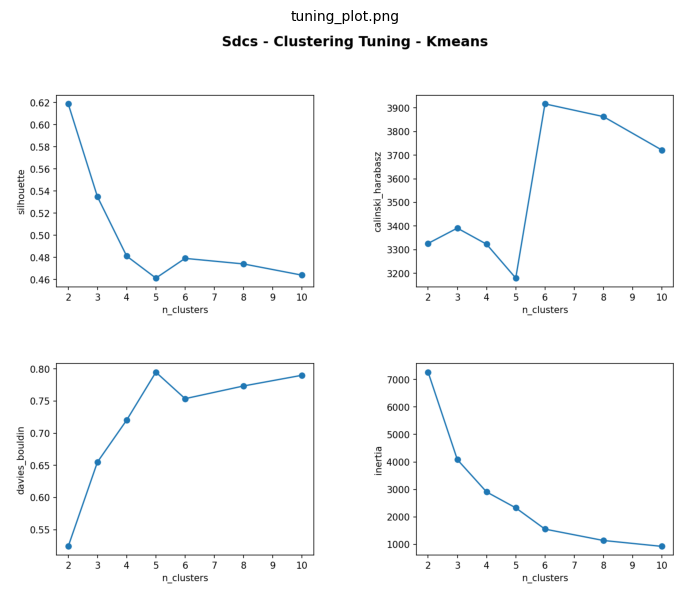

In [24]:
show_images(RUN_DIR, ["tuning_plot.png"])

In [25]:
results.sort_values("silhouette", ascending=False)

,n_clusters,silhouette,calinski_harabasz,davies_bouldin,noise_fraction,inertia
0,2,0.618872,3326.440775,0.523966,0.0,7267.062012
1,3,0.534891,3391.187301,0.655134,0.0,4084.667725
2,4,0.481263,3323.168868,0.720329,0.0,2907.927734
4,6,0.479173,3916.904256,0.753676,0.0,1554.540283
5,8,0.474149,3863.140449,0.773422,0.0,1140.814087
6,10,0.464009,3721.660364,0.790066,0.0,926.469604
3,5,0.461349,3179.660289,0.794906,0.0,2328.119629


### 3. Check artefatto: crosstab del candidato contro i metadati

**Come leggerlo:** un cluster quasi puro su una categoria di metadati (`lesion_side`, `dataset`) = artefatto, non struttura nuova.

In [26]:
list_combo_keys(RUN_DIR)[:10]  # per trovare il COMBO_KEY esatto sotto

['n_clusters=10',
 'n_clusters=2',
 'n_clusters=3',
 'n_clusters=4',
 'n_clusters=5',
 'n_clusters=6',
 'n_clusters=8']

In [27]:
COMBO_KEY = "n_clusters=5"
METADATA_COLUMN = "lesion_side"

crosstab_run(RUN_DIR, COMBO_KEY, METADATA_COLUMN)

lesion_side,left,right,unknown
row_0,,,
0,43,131,48
1,142,6,28
2,184,0,31
3,1,259,46
4,160,0,40


### 4. Vista globale multi-embedding

**Cosa mostra:** lo stesso check (tabella e `tuning_plot.png`) fianco a fianco su più `RUN_DIRS` — miglior `n_clusters` per Silhouette in ciascun embedding.
**Come leggerlo:** solo qualitativo — serve a vedere se il `k` migliore converge o cambia al variare di `n_components`.

In [28]:
RUN_DIRS = [
    NOTEBOOK_REPO_ROOT / "results/sdc/clustering/tuning/kmeans/umap/01-09_s2.1-schaefer-200-tian-s2_m_euclidean_nc2",
    NOTEBOOK_REPO_ROOT / "results/sdc/clustering/tuning/kmeans/umap/01-09_s2.1-schaefer-200-tian-s2_m_euclidean_nc2",
    NOTEBOOK_REPO_ROOT / "results/sdc/clustering/tuning/kmeans/umap/01-09_s2.1-schaefer-200-tian-s2_m_euclidean_nc2",
]
for run_dir in RUN_DIRS:
    if not run_dir.is_dir():
        raise FileNotFoundError(f"run directory not found: {run_dir}")

all_results = load_tuning_results(RUN_DIRS)
print(f"{len(all_results)} righe, run: {sorted(all_results['run'].unique())}")
all_results.sort_values("silhouette", ascending=False).groupby("run").head(1)

21 righe, run: ['01-09_s2.1_m_euclidean_nc2']


,run,n_clusters,silhouette,calinski_harabasz,davies_bouldin,noise_fraction,inertia
0,01-09_s2.1_m_euclidean_nc2,2,0.618872,3326.440775,0.523966,0.0,7267.062012


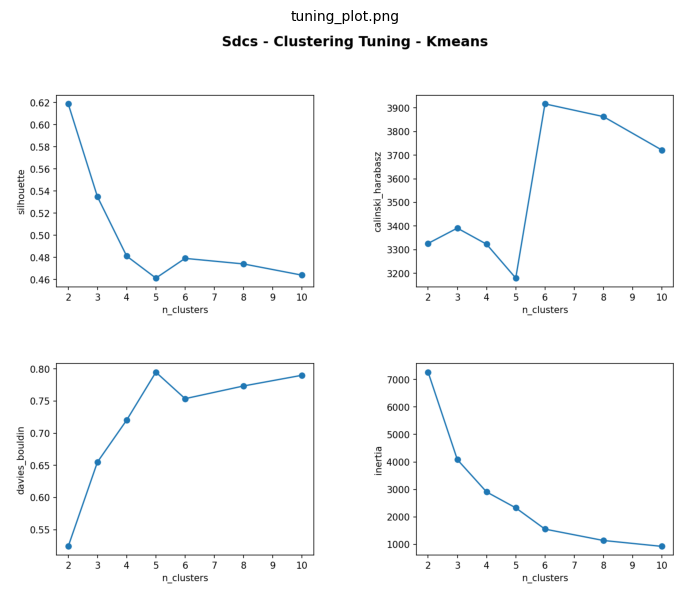

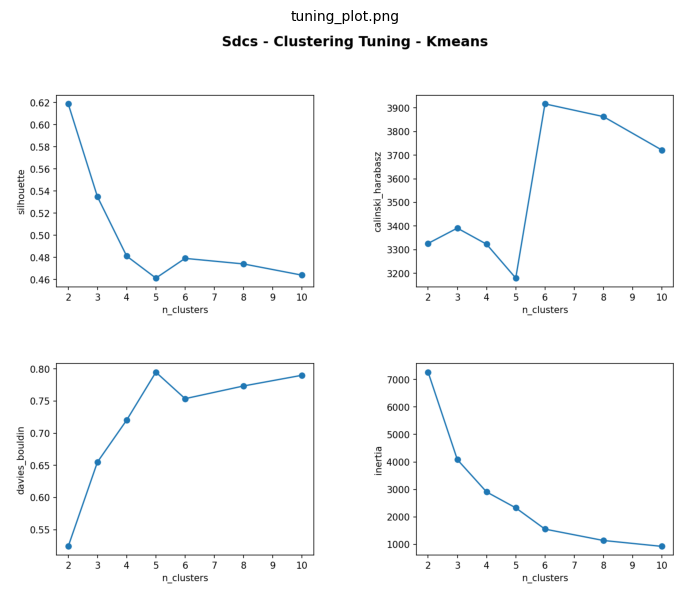

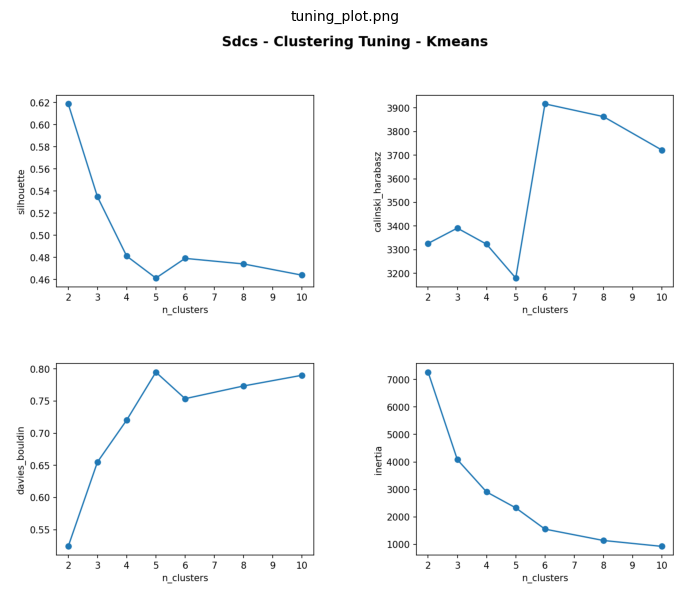

In [29]:
IMAGE_NAME = "tuning_plot.png"
for run_dir in RUN_DIRS:
    show_images(run_dir, [IMAGE_NAME])

## HDBSCAN

L'unico dei 5 senza check di stabilità (deterministico, no `random_state`, come agglomerative) E
senza un pre-check dedicato sul secondo asse: `min_cluster_size` × `min_samples` sono sweepati
insieme in un solo run (decisione esplicita di design - niente run ripetute/sequenziali), letti
dalla stessa heatmap a 2 parametri già usata per agglomerative `n_clusters`×`linkage`. Nessuna
diagnostica standalone dedicata (niente DBCV/condensation tree, scelta deliberata - nemmeno
l'esempio ufficiale sklearn li usa).

### 0. Scegli l'embedding

In [30]:
RUN_DIR = NOTEBOOK_REPO_ROOT / "results/sdc/clustering/tuning/hdbscan/umap/01-09_s2.1-schaefer-200-tian-s2_m_euclidean_nc2"

if not RUN_DIR.is_dir():
    raise FileNotFoundError(f"run directory not found: {RUN_DIR}")

results = pd.read_csv(RUN_DIR / "tuning_results.csv")
print(
    f"{len(results)} righe, min_cluster_size sweepate: {sorted(results['min_cluster_size'].unique())}, "
    f"min_samples sweepate: {sorted(results['min_samples'].unique())}"
)

18 righe, min_cluster_size sweepate: [np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(30), np.int64(50)], min_samples sweepate: [np.int64(5), np.int64(10), np.int64(20)]


### 1. `min_cluster_size` × `min_samples`

**Cosa mostra:** `tuning_plot.png` — heatmap, un subplot per Silhouette/CH/DB/`noise_fraction`, asse x = `min_cluster_size`, asse y = `min_samples`, colore = valore della metrica.
**Come leggerlo:** cerca la cella con il colore migliore, poi controlla `noise_fraction` per quella stessa cella (sezione 2) prima di fidartene.

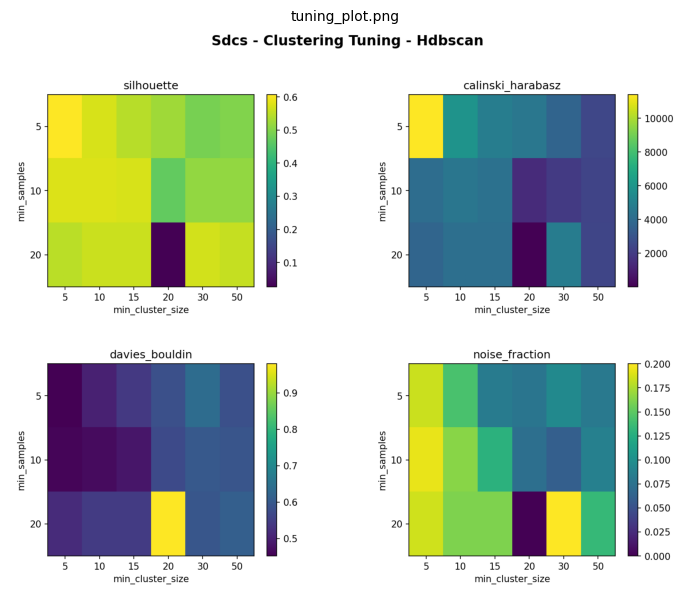

In [31]:
show_images(RUN_DIR, ["tuning_plot.png"])

In [32]:
results.sort_values("silhouette", ascending=False)

,min_cluster_size,min_samples,silhouette,calinski_harabasz,davies_bouldin,noise_fraction
0,5,5,0.607423,11406.589471,0.452308,0.184093
4,10,10,0.577659,4508.061724,0.467875,0.164433
1,5,10,0.576018,4113.518060,0.459371,0.193923
7,15,10,0.573002,4278.893322,0.483900,0.128686
3,10,5,0.572527,5854.452804,0.501718,0.142985
14,30,20,0.567699,4814.125141,0.592497,0.200179
8,15,20,0.560541,4201.492254,0.545040,0.161752
5,10,20,0.560541,4201.492254,0.545040,0.161752
17,50,20,0.555953,2422.122788,0.611485,0.134048
2,5,20,0.547654,3741.184459,0.517737,0.185880


### 2. Attenzione: `noise_fraction` va letta insieme agli indici, mai da sola

**Cosa mostra:** stessa tabella di sopra, filtrata su una soglia di `noise_fraction` (quota di soggetti classificati come rumore, label `-1`).
**Come leggerlo:** un `min_cluster_size` grande può dare indici ottimi solo perché scarta molti soggetti "difficili" come rumore — i pochi rimasti sembrano ben separati. Indice alto + `noise_fraction` alta = risultato ingannevole, non un vero candidato.

In [33]:
MAX_NOISE_FRACTION = 0.1  # soglia di esempio, cambia liberamente

results[results["noise_fraction"] <= MAX_NOISE_FRACTION].sort_values("silhouette", ascending=False)

,min_cluster_size,min_samples,silhouette,calinski_harabasz,davies_bouldin,noise_fraction
6,15,5,0.545358,4855.756713,0.540904,0.083110
9,20,5,0.525798,4527.702855,0.581921,0.077748
13,30,10,0.514429,1967.042155,0.598793,0.060769
16,50,10,0.512359,2372.099142,0.591273,0.087578
15,50,5,0.498507,2464.085283,0.580921,0.081323
12,30,5,0.488224,3708.586888,0.638750,0.094727
10,20,10,0.466936,1437.982475,0.571307,0.073280
11,20,20,0.027044,22.637522,0.980010,0.000000


### 3. Check artefatto: crosstab del candidato contro i metadati

**Come leggerlo:** come per gli altri metodi, più un controllo in più specifico a HDBSCAN — la riga `-1` (rumore) è mostrata a parte da `crosstab_run`: se sbilanciata per `lesion_side`/`dataset`, il rumore stesso è un artefatto, non solo i cluster.

In [34]:
list_combo_keys(RUN_DIR)[:10]  # per trovare il COMBO_KEY esatto sotto

['min_cluster_size=10,min_samples=10',
 'min_cluster_size=10,min_samples=20',
 'min_cluster_size=10,min_samples=5',
 'min_cluster_size=15,min_samples=10',
 'min_cluster_size=15,min_samples=20',
 'min_cluster_size=15,min_samples=5',
 'min_cluster_size=20,min_samples=10',
 'min_cluster_size=20,min_samples=20',
 'min_cluster_size=20,min_samples=5',
 'min_cluster_size=30,min_samples=10']

In [35]:
COMBO_KEY = "min_cluster_size=15,min_samples=10"
METADATA_COLUMN = "lesion_side"

crosstab_run(RUN_DIR, COMBO_KEY, METADATA_COLUMN)  # la riga -1 (se presente) sono i punti rumore

lesion_side,left,right,unknown
row_0,,,
-1,58,68,18
0,1,15,9
1,57,36,28
2,94,0,12
3,21,0,11
4,11,5,5
5,0,35,6
6,0,32,3
7,28,0,6


### 4. Vista globale multi-embedding

**Cosa mostra:** lo stesso check (tabella filtrata su `noise_fraction` e `tuning_plot.png`) fianco a fianco su più `RUN_DIRS` — miglior combinazione `min_cluster_size`/`min_samples` per Silhouette in ciascun embedding, sotto la stessa soglia di rumore usata in sezione 2.
**Come leggerlo:** solo qualitativo — serve a vedere se la combinazione migliore (e il suo livello di rumore) si ripete al variare di `n_components`.

In [36]:
RUN_DIRS = [
    NOTEBOOK_REPO_ROOT / "results/sdc/clustering/tuning/hdbscan/umap/01-09_s2.1-schaefer-200-tian-s2_m_euclidean_nc2",
    NOTEBOOK_REPO_ROOT / "results/sdc/clustering/tuning/hdbscan/umap/01-09_s2.1-schaefer-200-tian-s2_m_euclidean_nc2",
    NOTEBOOK_REPO_ROOT / "results/sdc/clustering/tuning/hdbscan/umap/01-09_s2.1-schaefer-200-tian-s2_m_euclidean_nc2",
]
for run_dir in RUN_DIRS:
    if not run_dir.is_dir():
        raise FileNotFoundError(f"run directory not found: {run_dir}")

all_results = load_tuning_results(RUN_DIRS)
print(f"{len(all_results)} righe, run: {sorted(all_results['run'].unique())}")

MAX_NOISE_FRACTION = 0.1  # stessa soglia di sezione 2, cambia liberamente
all_results[all_results["noise_fraction"] <= MAX_NOISE_FRACTION].sort_values("silhouette", ascending=False).groupby("run").head(1)

54 righe, run: ['01-09_s2.1_m_euclidean_nc2']


,run,min_cluster_size,min_samples,silhouette,calinski_harabasz,davies_bouldin,noise_fraction
6,01-09_s2.1_m_euclidean_nc2,15,5,0.545358,4855.756713,0.540904,0.08311


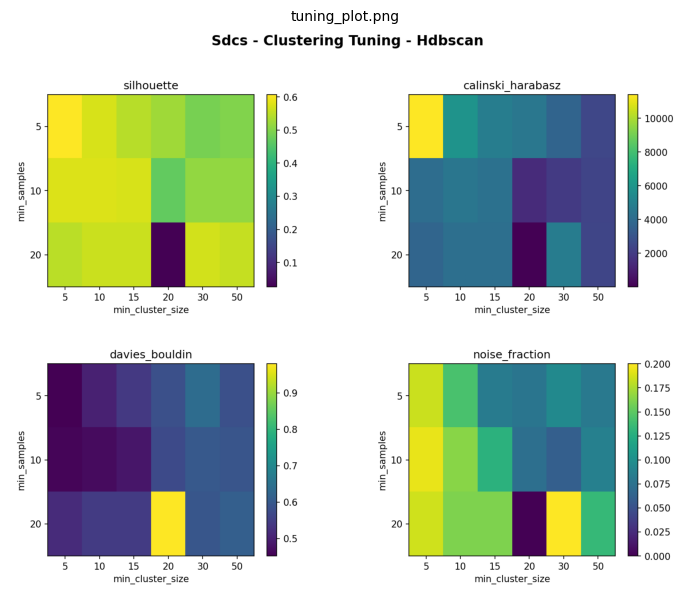

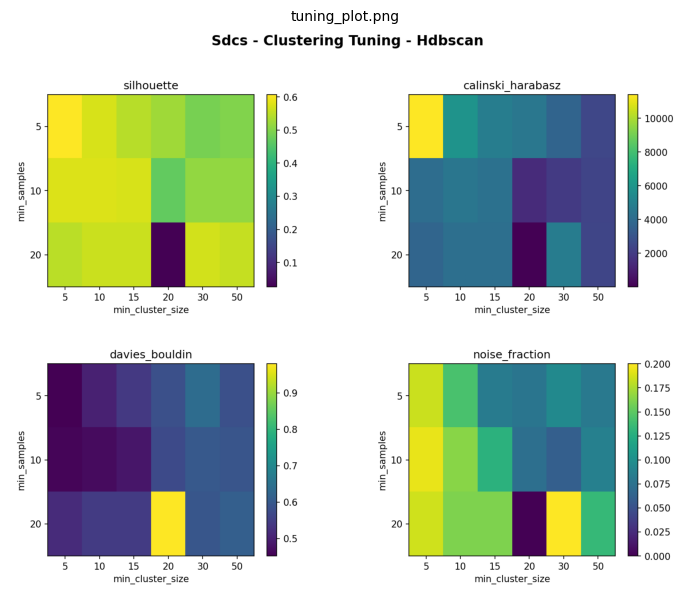

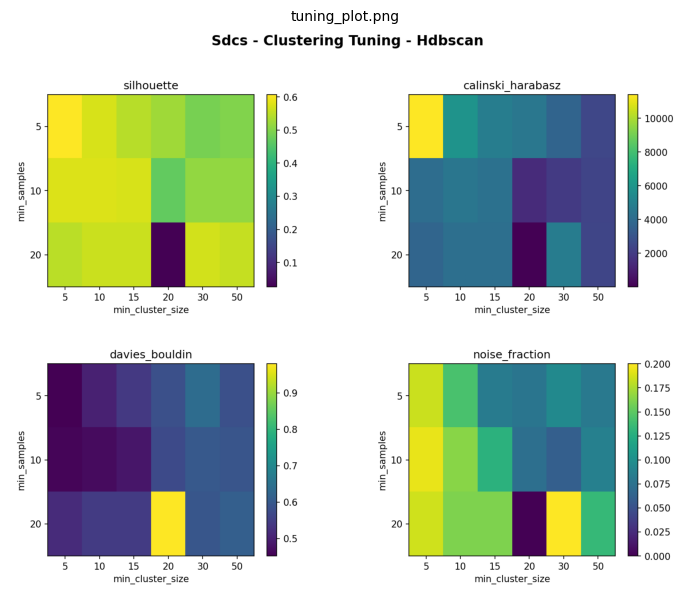

In [37]:
IMAGE_NAME = "tuning_plot.png"
for run_dir in RUN_DIRS:
    show_images(run_dir, [IMAGE_NAME])

## Spectral

`affinity` (`nearest_neighbors`/`rbf`) è il bivio, come `metric` per agglomerative - ma qui
**non c'è un pre-check dedicato tipo interclass-matrix**: le due sotto-sweep (una per affinity,
ciascuna col proprio iperparametro `n_neighbors`/`gamma`) finiscono unite nello stesso
`tuning_plot.png`, quindi la scelta si legge direttamente da lì. Nessuno stability check
(`assign_labels: "cluster_qr"` fissato in config rimuove l'instabilità ereditata da k-means che
sklearn userebbe di default). **Nota 28-08-26**: `eigengap_affinity=<affinity>.png` ora riflette
davvero l'`affinity`/iperparametro sweepato (prima era sempre calcolato a `base_params` fisso,
stesso bug già visto e corretto per il dendrogramma di agglomerative).

### 0. Scegli l'embedding

In [38]:
RUN_DIR = NOTEBOOK_REPO_ROOT / "results/sdc/clustering/tuning/spectral/umap/01-09_s2.1-schaefer-200-tian-s2_m_euclidean_nc2"

if not RUN_DIR.is_dir():
    raise FileNotFoundError(f"run directory not found: {RUN_DIR}")

results = pd.read_csv(RUN_DIR / "tuning_results.csv")
print(f"{len(results)} righe, affinity sweepate: {sorted(results['affinity'].unique())}, n_clusters sweepate: {sorted(results['n_clusters'].unique())}")

72 righe, affinity sweepate: ['nearest_neighbors', 'rbf'], n_clusters sweepate: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]


### 1. `affinity` + il suo iperparametro

**Cosa mostra:** `tuning_plot.png` — un subplot per Silhouette/CH/DB, asse x = `n_clusters`, una linea per combinazione `(affinity, iperparametro)` (es. `nearest_neighbors (n_neighbors=30)`, `rbf (gamma=1)`).
**Come leggerlo:** confronta le linee per scegliere `affinity`+iperparametro prima ancora di `n_clusters` — sotto, la tabella mostra le top-5 righe per `affinity` ordinate per Silhouette.

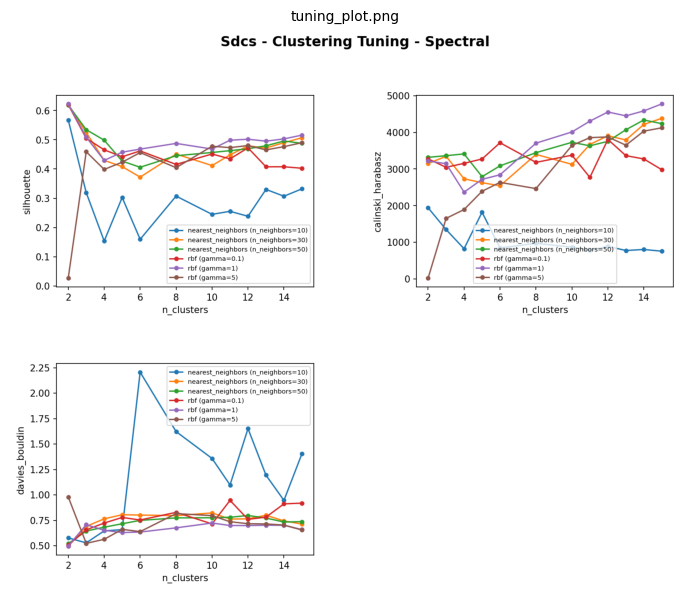

In [39]:
show_images(RUN_DIR, ["tuning_plot.png"])

In [40]:
results.sort_values("silhouette", ascending=False).groupby("affinity").head(5)

,n_clusters,n_neighbors,silhouette,calinski_harabasz,davies_bouldin,noise_fraction,affinity,gamma
37,2,NaN,0.622613,3215.949817,0.497034,0.0,rbf,1.0
1,2,30.0,0.621457,3149.005266,0.493919,0.0,nearest_neighbors,NaN
36,2,NaN,0.620008,3275.752380,0.507809,0.0,rbf,0.1
2,2,50.0,0.618633,3317.556941,0.520213,0.0,nearest_neighbors,NaN
0,2,10.0,0.567799,1940.013117,0.577236,0.0,nearest_neighbors,NaN
5,3,50.0,0.534538,3362.267665,0.644347,0.0,nearest_neighbors,NaN
4,3,30.0,0.524505,3344.584095,0.690270,0.0,nearest_neighbors,NaN
70,15,NaN,0.515766,4775.746839,0.659050,0.0,rbf,1.0
40,3,NaN,0.508904,3144.833780,0.706990,0.0,rbf,1.0
39,3,NaN,0.504869,3045.518385,0.656189,0.0,rbf,0.1


### 2. `n_clusters`, corroborato dall'eigengap

**Cosa mostra:** un file per `affinity`, un subplot per ogni valore sweepato del suo iperparametro — autovalori del grafo di affinità ordinati in ascissa, valore dell'autovalore in ordinata.
**Come leggerlo:** il k consigliato è l'indice appena prima del salto più grande tra due autovalori consecutivi (marcato nel plot). Criterio più diretto dei 3 indici generici qui, perché riflette la connettività del grafo che l'algoritmo usa internamente.

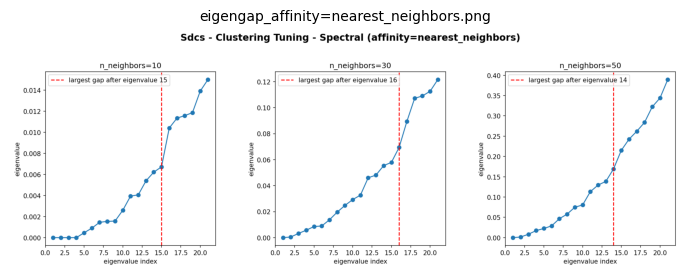

In [41]:
AFFINITY = "nearest_neighbors"
show_images(RUN_DIR, [f"eigengap_affinity={AFFINITY}.png"])

### 3. Check artefatto: crosstab del candidato contro i metadati

**Come leggerlo:** come per gli altri metodi. Nota pratica: questa run non salva `clusterings.npz` (disattivato quando `affinity` è sweepata) — serve `crosstab_refit`, che rifitta al volo invece di leggere etichette salvate.

In [42]:
PARAMS = {"n_clusters": 6, "affinity": "nearest_neighbors", "n_neighbors": 50, "assign_labels": "cluster_qr", "random_state": 0}
METADATA_COLUMN = "lesion_side"

crosstab_refit(RUN_DIR, PARAMS, METADATA_COLUMN)

lesion_side,left,right,unknown
row_0,,,
0,65,0,20
1,139,0,23
2,1,157,37
3,59,36,29
4,4,197,33
5,262,6,51


### 4. Vista globale multi-embedding

**Cosa mostra:** lo stesso check (tabella e `tuning_plot.png`) fianco a fianco su più `RUN_DIRS` — miglior combinazione `(affinity, iperparametro, n_clusters)` per Silhouette in ciascun embedding.
**Come leggerlo:** solo qualitativo — serve a vedere se `affinity`/`n_clusters` migliori si ripetono al variare di `n_components`.

In [43]:
RUN_DIRS = [
    NOTEBOOK_REPO_ROOT / "results/sdc/clustering/tuning/spectral/umap/01-09_s2.1-schaefer-200-tian-s2_m_euclidean_nc2",
    NOTEBOOK_REPO_ROOT / "results/sdc/clustering/tuning/spectral/umap/01-09_s2.1-schaefer-200-tian-s2_m_euclidean_nc2",
    NOTEBOOK_REPO_ROOT / "results/sdc/clustering/tuning/spectral/umap/01-09_s2.1-schaefer-200-tian-s2_m_euclidean_nc2",
]
for run_dir in RUN_DIRS:
    if not run_dir.is_dir():
        raise FileNotFoundError(f"run directory not found: {run_dir}")

all_results = load_tuning_results(RUN_DIRS)
print(f"{len(all_results)} righe, run: {sorted(all_results['run'].unique())}")
all_results.sort_values("silhouette", ascending=False).groupby(["run", "affinity"]).head(1)

216 righe, run: ['01-09_s2.1_m_euclidean_nc2']


,run,n_clusters,n_neighbors,silhouette,calinski_harabasz,davies_bouldin,noise_fraction,affinity,gamma
181,01-09_s2.1_m_euclidean_nc2,2,NaN,0.622613,3215.949817,0.497034,0.0,rbf,1.0
145,01-09_s2.1_m_euclidean_nc2,2,30.0,0.621457,3149.005266,0.493919,0.0,nearest_neighbors,NaN


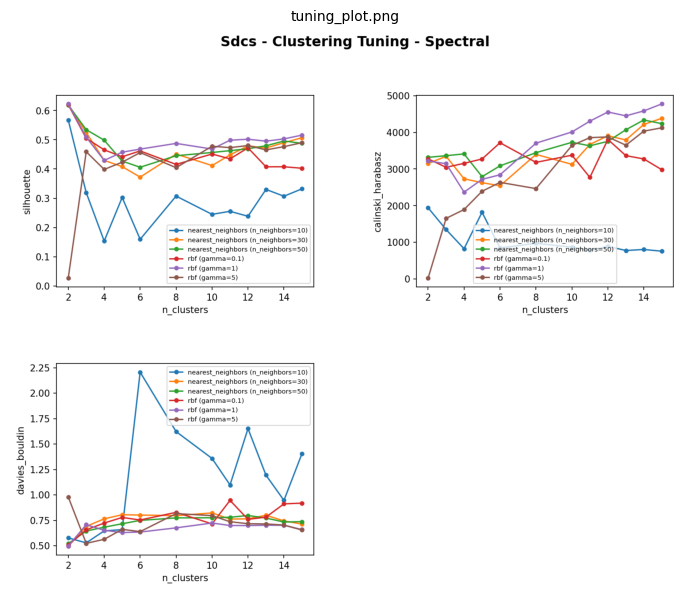

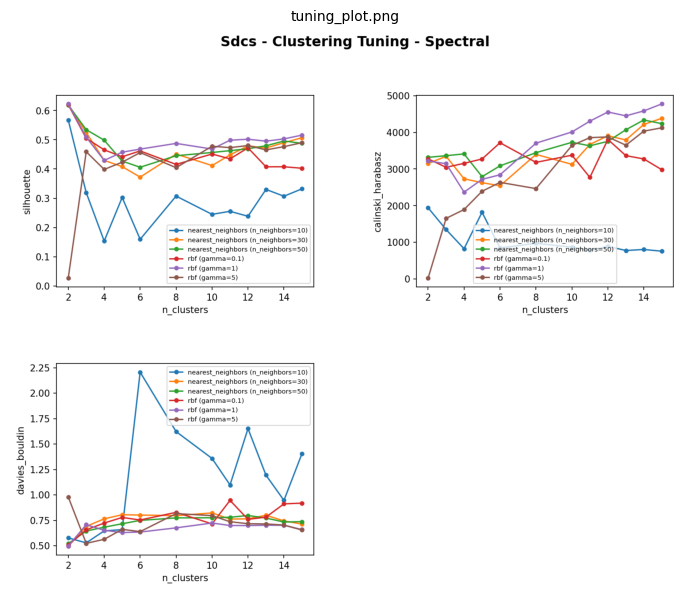

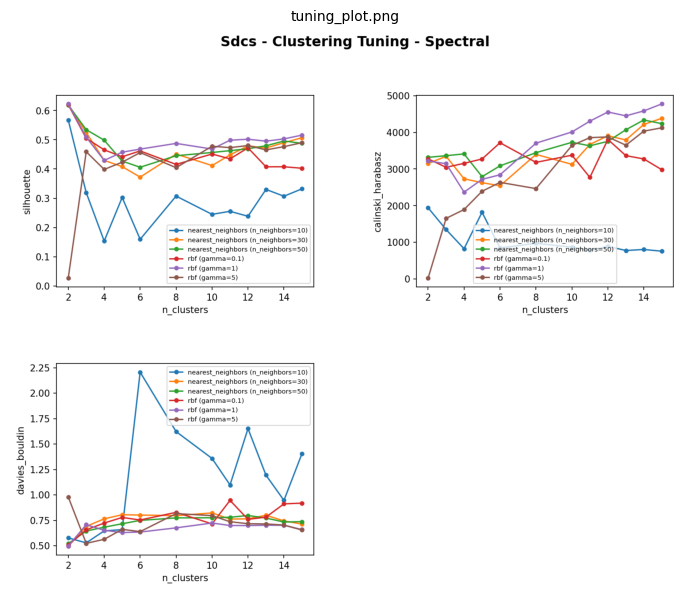

In [44]:
IMAGE_NAME = "tuning_plot.png"
for run_dir in RUN_DIRS:
    show_images(run_dir, [IMAGE_NAME])